# Constucting Neural Networks

Our goal in creating a neural network is the approximate the mapping $\mathbf{y} = f(\mathbf{x}) + \epsilon$. [...] Let us begin creating a deep learning model with PyTorch. Our aim will be to create and train a basic feed-foward network which can classifiy between hand written digits from `0` to `9` from the `MNIST` dataset.

In [1]:
# PyTorch imports,
import torch # <-- PyTorch
import torch.nn as nn # <-- Network architecture
from torch.utils.data import Dataset, DataLoader # <-- Wrappers for the data.
from torch.optim import Adam
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torchinfo import summary

# Importing,
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

# Printing versions,
print("System Version:", sys.version)
print("PyTorch version", torch.__version__)
print("TorchVision version", torchvision.__version__)
print("Numpy version", np.__version__)
print("Pandas version", pd.__version__)

System Version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.6.0+cpu
TorchVision version 0.21.0+cpu
Numpy version 1.26.4
Pandas version 2.2.2


#### Step 1: Data Loading

Let us begin by wrapping our dataset in way that PyTorch can understand it. It is best practice to define a custom class that inherits from `torch.utils.data.Dataset` to contain our data. The purpose of this is to allow our data to be put into batches by the `DataLoader`, perform pre-processing steps and to ensure future convenience. Below is the boilerplate code,

In [2]:
class MNISTDataset(Dataset):
    """PyTorch wrapper for the data. FOR DEMONSTRATION PURPOSES ONLY."""

    def __init__(self, data_dir, transform=None, target_transform=None):
        """Constuctor method. Loads the data and labels it."""
        pass

    def __len__(self):
        """Returns a tuple of which the first element is a PIL.Image.Image object and the other is the class label y_i."""
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        """Adds the class attribute `classes` stores the class names of the dataset."""
        return self.data.classes

However, in our case, `torchvision.datasets.MNIST` already creates a container object which inherits from the `Dataset` class. Its structure is the same as our own implementation above. When we have a custom dataset, we will have to define our `Dataset` container. Using TorchVision, we can download and/or load the MNIST dataset via (by setting `train=True` we use the training samples only),

In [4]:
# Defining transforms,
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Lambda(torch.flatten)
])

# Downloading MNIST,
train_data = MNIST(root="../datasets/mnist",
                   train=True, 
                   download=True, 
                   transform=transform, 
)

100%|██████████| 9.91M/9.91M [00:06<00:00, 1.54MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 188kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.51MB/s]


The transformation on the input defined by `transform` converts the the `PIL` images into tensors and peforms automatic scaling such that each tensor entry which represents a pixel value in the image has a value between `0` and `1`. It also flattens the tensor into a 1D tensor of length `28 x 28 = 784`. Furthermore, we define a `target_transform` that transforms the image labels $y_i \forall i$. Specifically, we use define a custome lambda function instead of using `transforms.Compose` (which assumes PIL images only) to convert the integer valued labels `0-9` into tensors that are then one-hot encoded via `F.one_hot`. Let us now visualise the images in the dataset, 

Image label: 5
Image shape: torch.Size([784])


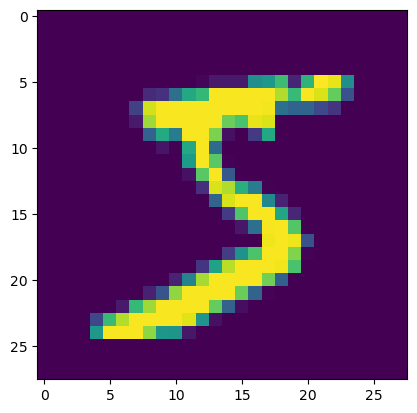

In [5]:
idx = 0
image, image_label = train_data[idx]
print(f"Image label: {image_label}")
print(f"Image shape: {image.shape}")
image = image.view(28, 28) 
plt.imshow(image.view(28, 28)) # <-- Reshape image tensor into 2D.
plt.show()

Now we create our `DataLoader` object which acts as the final stage of data prepartion before samples are fed into the model It is the responsibility of the `DataLoader` to organise the samples into batches and randomly shuffle the them (if needed).

In [6]:
BATCH_SIZE = 64
dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

To iterate through the batches,

In [7]:
for image_batch, labels in dataloader:
    print(f"Tensor: {image_batch.shape}")
    print(f"Labels: {labels}")
    break # <-- We only consider a single batch.

Tensor: torch.Size([64, 784])
Labels: tensor([0, 1, 7, 7, 5, 8, 5, 8, 4, 0, 4, 6, 5, 9, 9, 6, 2, 4, 8, 9, 6, 0, 5, 8,
        3, 0, 3, 4, 7, 8, 8, 6, 1, 8, 8, 5, 8, 7, 5, 0, 7, 8, 8, 2, 4, 0, 5, 3,
        3, 2, 7, 7, 0, 6, 9, 5, 7, 4, 2, 0, 3, 3, 7, 0])


### Step 2: Model Creation

In [8]:
class Model(nn.Module):
    """Class for the neural network."""
    def __init__(self):
        """The architecture of the neural network model."""
        super().__init__()

        # Our hidden layers,
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        """The forward propagation of the neural network model."""

        # Forward prop,
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.relu(x)

        return x

We can use the `summary` helper function from third-party `torchinfo` module which allows us to view the model layers, number of trainable parameters and forward pass size. Let us create our model and summarise it,

In [152]:
# Creating the neural network,
model = Model()
summary(model, input_size=(BATCH_SIZE, 784))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [64, 10]                  --
├─Linear: 1-1                            [64, 128]                 100,480
├─Linear: 1-2                            [64, 10]                  1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 6.51
Input size (MB): 0.20
Forward/backward pass size (MB): 0.07
Params size (MB): 0.41
Estimated Total Size (MB): 0.68

### Step 3: Model Training

Now we create the training loop to optimise the model using a choosen gradient descent method.

In [ ]:
# Hyperparameters,
n_epochs = 25
lr = 1e-2

# Setting the model to training mode,
model.train()

# Enabling CUDA (if possible),
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

# Creating the optimiser,
optimiser = Adam(model.parameters(), lr=lr)

# Specifying the loss function,
loss_fn = nn.CrossEntropyLoss()

"""TRAINING LOOP"""
epoch_losses = []
for epoch in range(1, n_epochs+1):
    running_loss = 0.0

    # Batch loop,
    for (X, y) in dataloader:

        # Resetting gradients,
        optimiser.zero_grad()

        # Moving tensors to training device,
        X, y = X.to(device), y.to(device)

        # Forward pass,
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        # Backward pass,
        loss.backward()
        optimiser.step()

        # Tracking loss,
        running_loss += loss.item()

    # Printing,
    epoch_loss = running_loss / len(dataloader)
    print(f"Epoch: {epoch}, Avg Loss: {epoch_loss}")
    epoch_losses.append(epoch_loss)

Training on: cpu
Epoch: 1, Avg Loss: 0.8702673993385168
Epoch: 2, Avg Loss: 0.7959233832511821
Epoch: 3, Avg Loss: 0.7892785375751158
Epoch: 4, Avg Loss: 0.7817390638310263
Epoch: 5, Avg Loss: 0.7810841370175388
Epoch: 6, Avg Loss: 0.7765462520216574
Epoch: 7, Avg Loss: 0.7940290155949623
Epoch: 8, Avg Loss: 0.7754204238909902
Epoch: 9, Avg Loss: 0.7853941243213377
Epoch: 10, Avg Loss: 0.7774940208712621
Epoch: 11, Avg Loss: 0.7753546389181223
Epoch: 12, Avg Loss: 0.7734181883492703
Epoch: 13, Avg Loss: 0.7717087618958975
Epoch: 14, Avg Loss: 0.7714371031789637
Epoch: 15, Avg Loss: 0.7718810501065589
Epoch: 16, Avg Loss: 0.7736356976444024
Epoch: 17, Avg Loss: 0.7645960420624279
Epoch: 18, Avg Loss: 0.771872742788624
Epoch: 19, Avg Loss: 0.7747705390394878
Epoch: 20, Avg Loss: 0.7640523762464015
Epoch: 21, Avg Loss: 0.7662834965153289
Epoch: 22, Avg Loss: 0.7763305456717131
Epoch: 23, Avg Loss: 0.7646154019751275
Epoch: 24, Avg Loss: 0.7619980799872229
Epoch: 25, Avg Loss: 0.7632633320

Now we plot average loss as a function of the epoch,

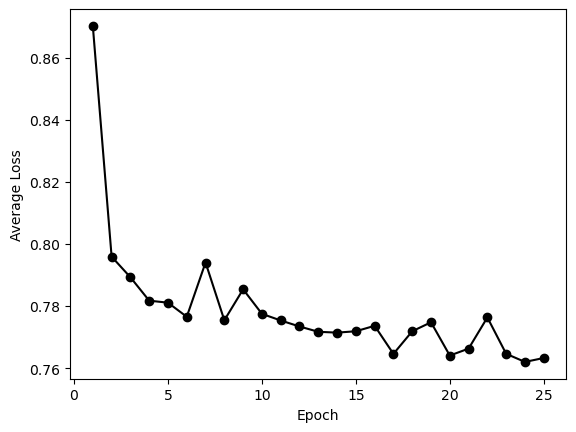

In [169]:
# Plotting,
epochs = np.arange(start=1, stop=n_epochs+1, step=1)
plt.plot(epochs, epoch_losses, marker="o", color="black")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.show()

### Step 4: Basic Model Evaluation

Since PyTorch is considered to be a more low-level frame compared to Keras/Tensorflow, it does not have a convenient built-in method to compute the classification accuracy of a model. This is for the sake of flexibility. We are expected to define the logic of the evaluation loop and define the exact metric we want to measure. Let us start by loading the test dataset for MNIST and create a new `DataLoader` container for it,

In [175]:
# Downloading MNIST and applying our transforms,
test_data = MNIST(root="./datasets/mnist",
                  train=False, 
                  download=True, 
                  transform=transform, 
)

# Creating a dataloader for the test samples,
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

Before we create a method to compute the classification accuracy, we must define a way to perform model inference. That is, a way to get model predictions. For our model, a convenient way to do this is the following,

In [ ]:
def predict(model, dataloader, device="cpu"):
    """This function performs model inference."""

    # Switch model to evaluation mode,
    model.eval()

    # Creating the predictions array,
    y_preds = []
    y_targets = []

    # Looping over all batches,
    with torch.no_grad():
        for (X, y) in dataloader:

            # Moving input tensor to training device,
            X, y = X.to(device), y.to(device)
            
            # Model forward pass,
            logits = model(X)

            # Computing the prediction,
            y_pred = torch.argmax(logits, dim=1)
            y_preds.append(y_pred)

            # Storing labels,
            y_targets.append(y)

    # Concatening batch predictions (and labels),
    y_preds = torch.cat(y_preds, dim=0)
    y_targets = torch.cat(y_targets, dim=0)

    # Returning predictions,
    return y_preds, y_targets

Now we create a function called `compute_accuracy` which uses the predictions to compute the classification accuracy of the model,

In [220]:
def compute_accuracy(preds, targets):
    """Computes the accuracy from the boolean tensor."""
    return torch.mean((preds == targets).float()).item()

Computing the accuracy metric,

In [219]:
# Model inference,
preds, targets = predict(model, test_dataloader, device="cpu")

# Computing classification accuracy,
score = compute_accuracy(preds, targets)
score

0.6574000120162964